In [1]:
!pip install -qu gensim




Access is denied.


In [7]:
import numpy as np
import pandas as pd 
import re
import pickle
import gensim.downloader

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [4]:
import os
print(os.getcwd())          # shows current folder Jupyter is running in
print(os.listdir())         # lists files in that folder

C:\Users\Umme Amreen Saba
[' Dictionary-Comprehension_task12.ipynb', ' while_Loop_task7.ipynb', '.anaconda', '.codex', '.conda', '.condarc', '.continuum', '.copilot', '.git', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.m2', '.matplotlib', '.ollama', '.python_history', '.spyder-py3', '.streamlit', '.vscode', '.vscode-shared', '23classwork.ipynb', 'activation_function.ipynb', 'advance_statisticproject.ipynb', 'Advertising.csv', 'amazon_reviews (1).csv', 'amazon_reviews.csv', 'amex.txt', 'anaconda_projects', 'ANN_24.ipynb', 'ANN_project.ipynb', 'ANN_Regression_Model.keras', 'AppData', 'Application Data', 'AQI (1).csv', 'assigment.ipynb', 'banana_quality_dataset.csv', 'Boston-house-price-data.csv', 'car_MSRP.csv', 'car_msrp_model.pkl', 'Car_Prediction.ipynb', 'classification_regression.ipynb', 'code.ipynb', 'columnTransformer.ipynb', 'conditional_statements_3_task6.ipynb', 'Cookies', 'credit_card_fraud_dataset.csv', 'customer_encoding.csv'

In [5]:
import os
print(os.getcwd())

C:\Users\Umme Amreen Saba


In [10]:
df = pd.read_csv(r"C:\Users\Umme Amreen Saba\Tweets.csv")
#df = pd.read_csv("Tweets.csv")

In [11]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [12]:
df = df[['text','airline_sentiment']]

In [13]:
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(188)

In [15]:
df.dropna(inplace=True)

In [16]:
df.reset_index(drop=True,inplace=True)

In [17]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+"," ",text)

    text = re.sub(r"@\w+"," @ ",text)

    text = re.sub(r"[^a-z@ ]"," ",text)

    text = re.sub(r"\s+"," ",text).strip()

    return text.split()

In [18]:
import gensim.downloader
print(list(gensim.downloader.info()['models']))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [19]:
glove = gensim.downloader.load("glove-twitter-200")

[==================================================] 100.0% 758.5/758.5MB downloaded


In [21]:
vocabulary = set()

for sentence in df["text"]:
    vocabulary.update(clean_text(sentence))

embedding_lookup = {}

for word in vocabulary:
    if word in glove:
        embedding_lookup[word] = glove[word]

with open("embedding_lookup.pkl", "wb") as f:
    pickle.dump(embedding_lookup, f)

print("Saved Successfully")
print("Vocabulary Size:", len(embedding_lookup))

Saved Successfully
Vocabulary Size: 9569


In [22]:
def sentence_vector(sentence):

    words = clean_text(sentence)

    valid_words = [word for word in words if word in glove]

    if len(valid_words)==0:

        return np.zeros(200)

    return glove.get_mean_vector(valid_words)

In [23]:
X = np.array(df['text'].apply(sentence_vector).tolist())

In [24]:
X.shape

(14640, 200)

In [25]:
encoder = LabelEncoder()

y = encoder.fit_transform(df['airline_sentiment'])

In [26]:
pickle.dump(encoder,open("label_encoder.pkl","wb"))

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [28]:
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train,test_size=0.20,random_state=42,stratify=y_train)

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [30]:
pickle.dump(scaler,open("scaler.pkl","wb"))

In [31]:
!pip install optuna

Access is denied.


In [32]:
import optuna
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Input

from tensorflow.keras.regularizers import l1_l2

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import Nadam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [33]:
def objective(trial):

    learning_rate = trial.suggest_float("learning_rate",1e-5,1e-2,log=True)

    optimizer_name = trial.suggest_categorical("optimizer",["Adam","RMSprop","Nadam"])

    activation = trial.suggest_categorical("activation",["relu","tanh","elu"])

    batch_size = trial.suggest_categorical("batch_size",[32,64,128])

    n_layers = trial.suggest_int("n_layers",2,5)

    model = Sequential()

    model.add(Input(shape=(200,)))

    for i in range(n_layers):

        units = trial.suggest_categorical(f"units_{i}",[64,128,256,512])

        dropout = trial.suggest_float(f"dropout_{i}",0.10,0.50)

        reg = trial.suggest_float(f"reg_{i}",1e-6,1e-3,log=True)

        model.add(Dense(
            units=units,
            activation=activation,
            kernel_regularizer=l1_l2(reg,reg)
        ))

        model.add(BatchNormalization())

        model.add(Dropout(dropout))

    model.add(Dense(3,activation="softmax"))

    optimizer_dict = {

        "Adam":Adam(learning_rate),

        "RMSprop":RMSprop(learning_rate),

        "Nadam":Nadam(learning_rate)

    }

    model.compile(

        optimizer=optimizer_dict[optimizer_name],

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    early_stop = EarlyStopping(

        monitor="val_accuracy",

        patience=7,

        restore_best_weights=True,

        mode="max"

    )

    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6

    )

    history = model.fit(

        X_train,

        y_train,

        validation_data=(X_val,y_val),

        epochs=30,

        batch_size=batch_size,

        callbacks=[early_stop,reduce_lr],

        verbose=0

    )

    return max(history.history["val_accuracy"])

In [34]:
study = optuna.create_study(

    direction="maximize",

    sampler=optuna.samplers.TPESampler(seed=42))

[I 2026-07-03 15:09:31,558] A new study created in memory with name: no-name-3fb9ccd0-1a80-479d-ac71-d9d8e60c2ddd


In [35]:
study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True)

  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-03 15:10:51,814] Trial 0 finished with value: 0.7955612540245056 and parameters: {'learning_rate': 0.0001329291894316216, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 32, 'n_layers': 2, 'units_0': 64, 'dropout_0': 0.17336180394137352, 'reg_0': 8.179499475211674e-06, 'units_1': 512, 'dropout_1': 0.15579754426081674, 'reg_1': 7.523742884534855e-06}. Best is trial 0 with value: 0.7955612540245056.
[I 2026-07-03 15:14:07,431] Trial 1 finished with value: 0.7831839323043823 and parameters: {'learning_rate': 0.00012562773503807024, 'optimizer': 'RMSprop', 'activation': 'tanh', 'batch_size': 32, 'n_layers': 5, 'units_0': 64, 'dropout_0': 0.3736932106048628, 'reg_0': 2.091498132903561e-05, 'units_1': 512, 'dropout_1': 0.20351199264000677, 'reg_1': 9.717775305059631e-05, 'units_2': 256, 'dropout_2': 0.48783385110582345, 'reg_2': 0.00021154290797261214, 'units_3': 64, 'dropout_3': 0.1353970008207678, 'reg_3': 3.87211803217458e-06, 'units_4': 256, 'dropout_4': 0.43149500366

In [36]:
print("Best Validation Accuracy :")
print(study.best_trial.value)

Best Validation Accuracy :
0.8028169274330139


In [37]:
best = study.best_trial.params
print(best)

{'learning_rate': 0.007107091371554557, 'optimizer': 'Nadam', 'activation': 'elu', 'batch_size': 64, 'n_layers': 4, 'units_0': 256, 'dropout_0': 0.16642478388201495, 'reg_0': 5.950443044133894e-05, 'units_1': 256, 'dropout_1': 0.2795422487985507, 'reg_1': 0.0003151031895233303, 'units_2': 256, 'dropout_2': 0.16503130465496502, 'reg_2': 6.221440683215619e-05, 'units_3': 256, 'dropout_3': 0.36099478624829057, 'reg_3': 0.0009028658835380583}


(11712, 200)
(11712,)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_139 (Dense)               │ (None, 256)            │        51,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_109         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_109 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_140 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_110         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_110 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_141 (Dense)               │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_111         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_111 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_142 (Dense)               │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 254,467 (994.01 KB)

 Trainable params: 252,419 (986.01 KB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.7070 - loss: 1.1402 - val_accuracy: 0.7645 - val_loss: 1.2188 - learning_rate: 0.0094
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7648 - loss: 0.9305 - val_accuracy: 0.7807 - val_loss: 0.9121 - learning_rate: 0.0094
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7822 - loss: 0.8415 - val_accuracy: 0.8012 - val_loss: 0.7905 - learning_rate: 0.0094
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7880 - loss: 0.7994 - val_accuracy: 0.7918 - val_loss: 0.7625 - learning_rate: 0.0094
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7988 - loss: 0.7326 - val_accuracy: 0.8012 - val_loss: 0.7360 - learning_rate: 0.0094
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8068 - loss: 0.6979 - val_accuracy: 0.8012 - val_loss: 0.7175 - learning_rate: 0.0094
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8074 - loss: 0.6720 -

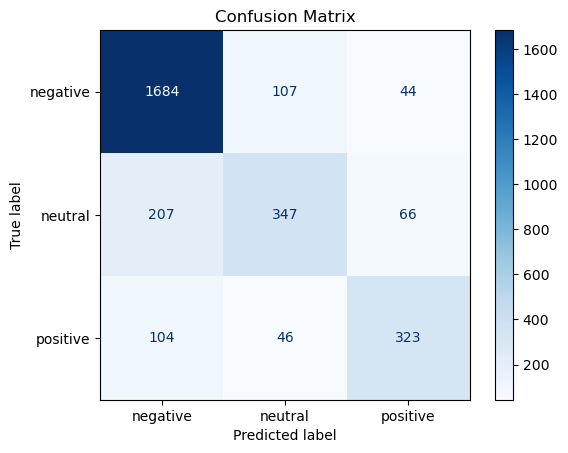

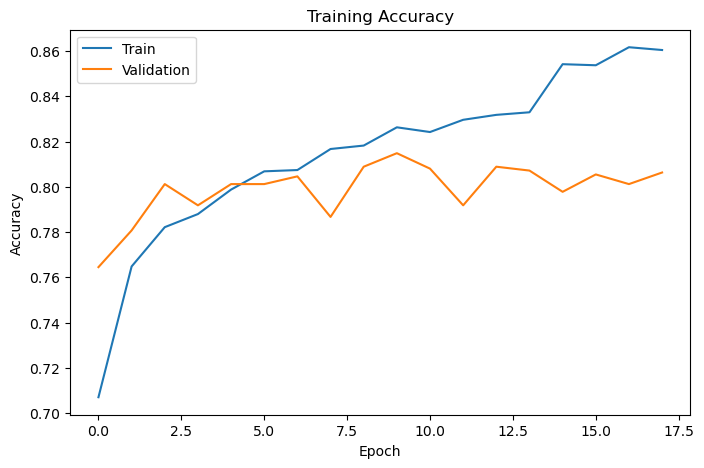

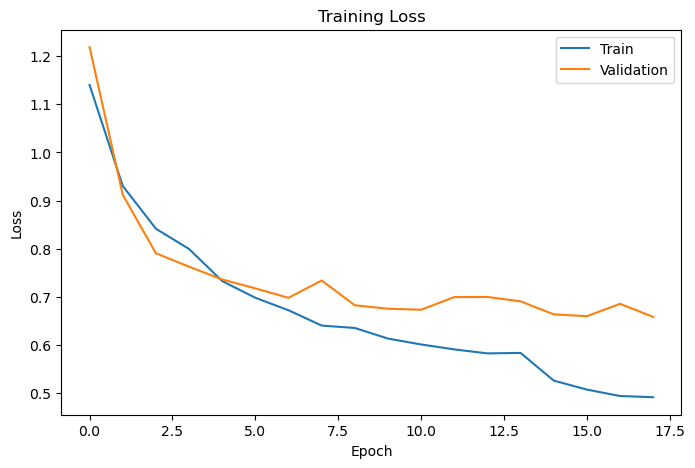


Model Saved Successfully!


In [38]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -----------------------------
# Best Parameters
# -----------------------------

best = {
    'learning_rate': 0.009415244195298792,
    'optimizer': 'Adam',
    'activation': 'relu',
    'batch_size': 128,
    'n_layers': 3,
    'units_0': 256,
    'dropout_0': 0.4819038198762265,
    'reg_0': 3.276616214882557e-06,
    'units_1': 256,
    'dropout_1': 0.3258921610124521,
    'reg_1': 2.004525492982464e-05,
    'units_2': 512,
    'dropout_2': 0.25417429799364333,
    'reg_2': 2.6570895590079712e-05
}

# -----------------------------
# Merge Train + Validation
# -----------------------------

X_full = np.vstack((X_train, X_val))
y_full = np.concatenate((y_train, y_val))

print(X_full.shape)
print(y_full.shape)

# -----------------------------
# Build Model
# -----------------------------

model = Sequential()

model.add(Input(shape=(X_full.shape[1],)))

for i in range(best["n_layers"]):

    model.add(
        Dense(
            units=best[f'units_{i}'],
            activation=best["activation"],
            kernel_regularizer=l1_l2(
                l1=best[f'reg_{i}'],
                l2=best[f'reg_{i}']
            )
        )
    )

    model.add(BatchNormalization())

    model.add(
        Dropout(best[f'dropout_{i}'])
    )

model.add(Dense(3, activation='softmax'))

# -----------------------------
# Compile
# -----------------------------

optimizer = Adam(
    learning_rate=best["learning_rate"]
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# Callbacks
# -----------------------------

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    mode='max',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# -----------------------------
# Train Final Model
# -----------------------------

history = model.fit(
    X_full,
    y_full,
    validation_split=0.1,
    epochs=100,
    batch_size=best["batch_size"],
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

# -----------------------------
# Predictions
# -----------------------------

y_prob = model.predict(X_test, verbose=0)

y_pred = np.argmax(y_prob, axis=1)

# -----------------------------
# Metrics
# -----------------------------

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Accuracy Curve
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train')

plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.show()

# -----------------------------
# Loss Curve
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train')

plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

# -----------------------------
# Save Model
# -----------------------------

model.save("sentiment_model.keras")

print("\nModel Saved Successfully!")